# Döviz Volatilite ve Performans Analizi (Ocak 2024)

Bu çalışmada USD baz alınarak EUR, GBP, JPY ve TRY para birimlerinin:

- Zaman içindeki performansı  
- Günlük dalgalanma (volatilite)  

analiz edilmiştir.

## Veri Toplama

Veriler Frankfurter API üzerinden alınmıştır.

- Baz para birimi: USD  
- Para birimleri: EUR, GBP, JPY, TRY  
- Tarih aralığı: Ocak 2024

In [2]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

url = "https://api.frankfurter.app/2024-01-01..2024-02-01"
params = {
        "from":"USD",
        "to":"EUR,TRY,GBP,JPY"
        }

response = requests.get(url,params=params)
data = response.json()
response.status_code

print(data)

results = []

for date,rates in data["rates"].items():
    for currency , value in rates.items():
        results.append({
            "date":date,
            "currency":currency,
             "rate":value})

df = pd.DataFrame(results)

{'amount': 1.0, 'base': 'USD', 'start_date': '2023-12-29', 'end_date': '2024-02-01', 'rates': {'2023-12-29': {'EUR': 0.90498, 'GBP': 0.78647, 'JPY': 141.48, 'TRY': 29.55}, '2024-01-02': {'EUR': 0.91274, 'GBP': 0.79085, 'JPY': 142.1, 'TRY': 29.726}, '2024-01-03': {'EUR': 0.91583, 'GBP': 0.79192, 'JPY': 143.02, 'TRY': 29.781}, '2024-01-04': {'EUR': 0.91299, 'GBP': 0.78771, 'JPY': 144.17, 'TRY': 29.772}, '2024-01-05': {'EUR': 0.91567, 'GBP': 0.7894, 'JPY': 145.2, 'TRY': 29.841}, '2024-01-08': {'EUR': 0.91358, 'GBP': 0.78705, 'JPY': 144.52, 'TRY': 29.894}, '2024-01-09': {'EUR': 0.91408, 'GBP': 0.78554, 'JPY': 144.09, 'TRY': 29.939}, '2024-01-10': {'EUR': 0.91358, 'GBP': 0.78589, 'JPY': 145.29, 'TRY': 29.974}, '2024-01-11': {'EUR': 0.91017, 'GBP': 0.78406, 'JPY': 145.36, 'TRY': 29.997}, '2024-01-12': {'EUR': 0.91391, 'GBP': 0.78551, 'JPY': 145.47, 'TRY': 30.095}, '2024-01-15': {'EUR': 0.91366, 'GBP': 0.78643, 'JPY': 145.88, 'TRY': 30.1}, '2024-01-16': {'EUR': 0.91895, 'GBP': 0.79101, 'JPY':

## Veri Yapısı

API'den alınan veriler düzenlenerek aşağıdaki sütunlar oluşturulmuştur:

- date → tarih  
- currency → para birimi  
- rate → döviz kuru  

Bu yapı analiz için uygun hale getirilmiştir.

## Veri Hazırlama ve Özellik Üretimi

- Tarih verisi datetime formatına çevrildi  
- Yıl ve ay bilgileri çıkarıldı  
- Veri Ocak 2024 ile filtrelendi  
- Günlük yüzdesel değişim (daily_pct_change) hesaplandı  

Bu metrik, günlük değişimleri ölçmek için kullanılır.

In [5]:
df["date"] = pd.to_datetime(df["date"],dayfirst=True)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df = df[df["year"]==2024]
df = df[df["month"]==1]

df["rate"]=df["rate"].round(2)
df.sort_values(["currency","date"],inplace=True)
df["daily_pct_change"] = df.groupby("currency")["rate"].pct_change() * 100
df["daily_pct_change"]= df["daily_pct_change"].round(2)
df=df.reset_index(drop=True)


df

,date,currency,rate,year,month,daily_pct_change
0,2024-01-02,EUR,0.91,2024,1,NaN
1,2024-01-03,EUR,0.92,2024,1,1.10
2,2024-01-04,EUR,0.91,2024,1,-1.09
3,2024-01-05,EUR,0.92,2024,1,1.10
4,2024-01-08,EUR,0.91,2024,1,-1.09
...,...,...,...,...,...,...
83,2024-01-25,TRY,30.28,2024,1,0.36
84,2024-01-26,TRY,30.30,2024,1,0.07
85,2024-01-29,TRY,30.35,2024,1,0.17
86,2024-01-30,TRY,30.36,2024,1,0.03


## Performans Analizi (Endekslenmiş)

Her para biriminin başlangıç değeri 100 kabul edilerek performans karşılaştırması yapılmıştır.

Yorumlama:
- 100 üzeri → USD karşısında değer kazanımı  
- 100 altı → USD karşısında değer kaybı  

Bu grafik trendi (yönü) gösterir.

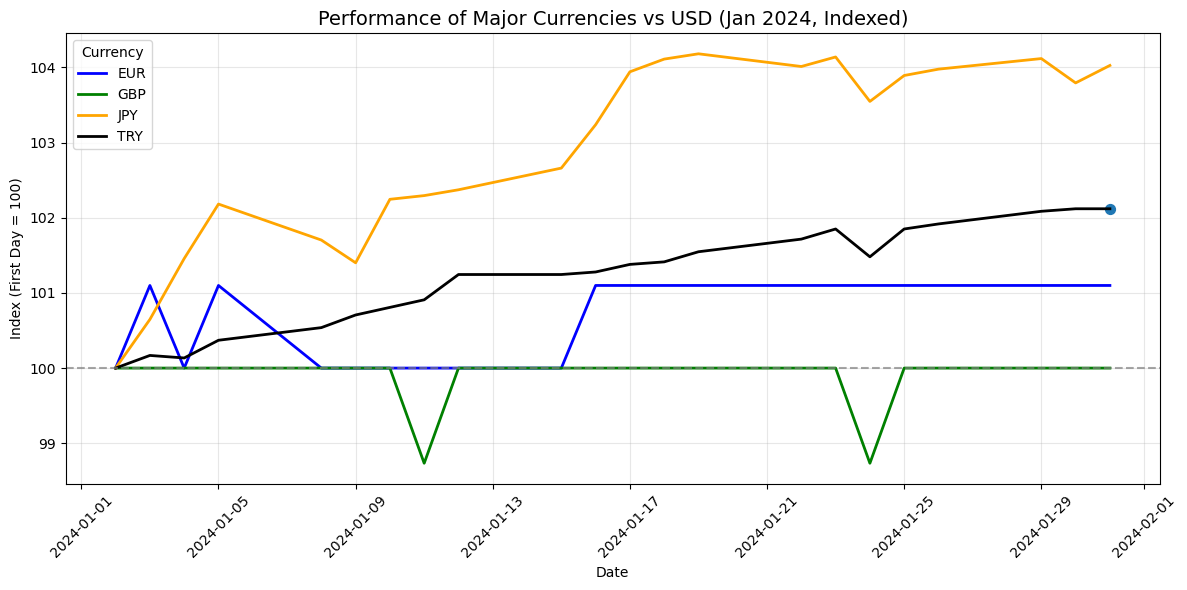

In [6]:
df_indexed = df.copy()

df_indexed["indexed_rate"] = df_indexed.groupby("currency")["rate"].transform(
    lambda x: (x / x.iloc[0]) * 100
)

plt.figure(figsize=(12,6))

colors = {
    "EUR": "blue",
    "TRY": "black",
    "GBP": "green",
    "JPY": "orange"
}

for currency in df_indexed["currency"].unique():
    subset = df_indexed[df_indexed["currency"] == currency]
    plt.plot(
        subset["date"],
        subset["indexed_rate"],
        label=currency,
        color=colors.get(currency, "black"),
        linewidth=2
    )

plt.title("Performance of Major Currencies vs USD (Jan 2024, Indexed)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Index (First Day = 100)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend(title="Currency")
plt.tight_layout()
plt.axhline(y=100, color="gray", linestyle="--", alpha=0.7)
plt.scatter(subset["date"].iloc[-1], subset["indexed_rate"].iloc[-1], s=50)
plt.show()

In [11]:
volatility = df.groupby("currency")["daily_pct_change"].std().sort_values(ascending=False) 
print(volatility)

# Volatilite, günlük yüzdesel değişimlerin standart sapması ile hesaplanmıştır.
# - Yüksek değer → daha fazla dalgalanma (risk)  
# - Düşük değer → daha stabil yapı

currency
GBP    0.570201
EUR    0.545274
JPY    0.409971
TRY    0.146713
Name: daily_pct_change, dtype: float64


## Volatilite Karşılaştırması

Bu grafik, para birimlerinin dalgalanma seviyelerini karşılaştırır.

Öne çıkan bulgular:
- GBP ve EUR en yüksek volatiliteye sahip  
- JPY orta seviyede volatilite gösteriyor  
- TRY daha düşük volatilite ile daha stabil görünmektedir  

Not:  
Trend (yükselmek) ile volatilite (dalgalanmak) farklı kavramlardır.

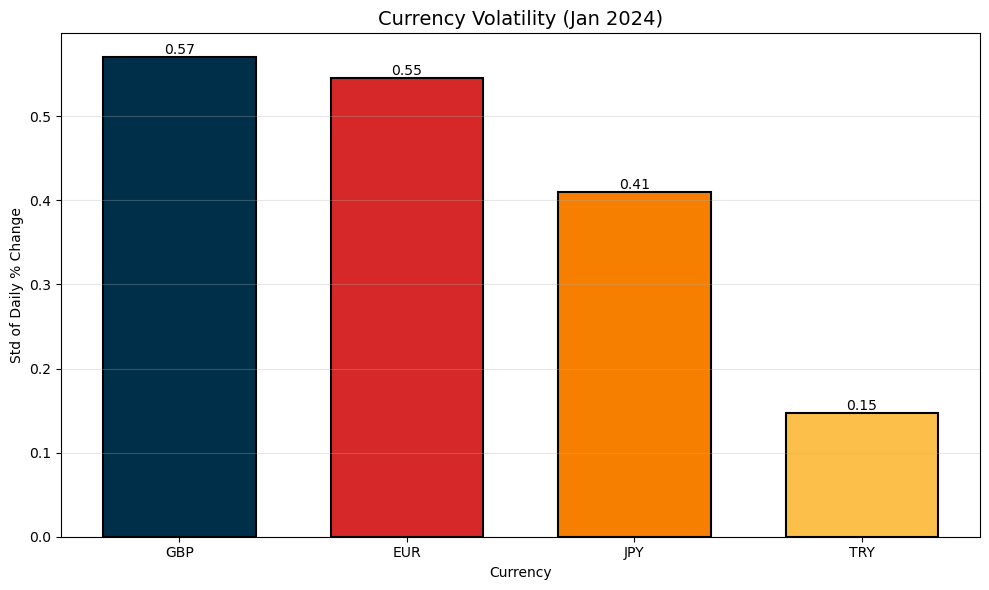

In [12]:
plt.figure(figsize=(10,6))

colors = ["#003049", "#D62828", "#F77F00", "#FCBF49"]

bars = plt.bar(
    volatility.index,
    volatility.values,
    color=colors,
    width=0.67,              
    edgecolor="black",      
    linewidth=1.5          
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Currency Volatility (Jan 2024)", fontsize=14)
plt.xlabel("Currency")
plt.ylabel("Std of Daily % Change")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()